# Metabolite-set enrichment analysis (MSEA)

A list of significant metabolite names doesn't tell a biological story on its own. **Metabolite-Set Enrichment Analysis (MSEA)** tests whether your hit list is over-represented in curated biochemical pathways — the same logic as gene-set enrichment, but with metabolite sets.

This tutorial covers:

1. The **metabolite ID landscape** — HMDB, KEGG, ChEBI, LipidMaps — what each is for
2. `ov.metabol.map_ids` — resolving names to IDs (and what to do about misses)
3. **ORA** (Over-Representation Analysis) — Fisher's-exact on a hit list
4. **GSEA-style** — rank-based enrichment from a full ordered list
5. Interpreting results — what to trust, what to question

**Dataset**: cachexia NMR, picking up where `t_metabol_01_intro.ipynb` left off.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import omicverse as ov

ov.plot_set()

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.1.2rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## 1 — The metabolite ID landscape

Unlike genes (where Ensembl / NCBI / HGNC each have a mostly-unique ID per gene), metabolites have several complementary databases:

| Database | Focus | Typical ID | Scope |
|---|---|---|---|
| **HMDB** (Human Metabolome DB) | endogenous human metabolites + concentrations in body fluids | `HMDB0000122` (glucose) | ~114 k compounds; strongest for biofluid metabolomics |
| **KEGG compound** | enzymatic reactions + pathways | `C00031` (glucose) | ~19 k compounds; pairs with KEGG pathway IDs |
| **ChEBI** | chemistry-of-biological-interest ontology | `CHEBI:17234` (glucose) | ~130 k; rich structural taxonomy |
| **LipidMaps** | lipids specifically | `LMGP01010558` (PC 34:1) | ~44 k lipid species |

Almost every metabolite has IDs in 2-3 of these, and papers have converged on **KEGG compound IDs** as the lingua franca for pathway analysis (because KEGG is the most-complete public pathway database).

### The licensing gotcha

- **KEGG** restricts commercial use and bulk download; you can query their REST API freely but can't ship the full pathway database inside a Python package. omicverse ships a **curated subset** (~35 pathways, 95 metabolites) enough to run the tutorials; for full-coverage analysis use their web API.
- **HMDB** is CC-BY-NC — ship-in-your-tool is OK for non-commercial use.
- **LipidMaps** and **ChEBI** are CC-BY — freely shippable.

`ov.metabol.map_ids` looks every name up against **PubChem** (synonym-aware) and pulls HMDB / KEGG / ChEBI cross-refs in one call. Every resolved name is cached at `~/.cache/omicverse/metabol/` so repeat calls are free. For bulk offline use, `ov.metabol.fetch_chebi_compounds()` downloads ~54k ChEBI compounds once (~15 MB, cached) and `map_ids(..., mass_db=ch)` looks up against the local DataFrame first — avoids per-name HTTP round-trips.

## 2 — Run the canonical preprocessing + differential

Short repeat of notebook 1 so the downstream enrichment has a DEG table to work on.

In [2]:
csv_path = ov.datasets.download_data(
    url='https://rest.xialab.ca/api/download/metaboanalyst/human_cachexia.csv',
    file_path='human_cachexia.csv',
    dir='./metabol_data',
)
adata = ov.metabol.read_metaboanalyst(csv_path, group_col='Muscle loss')
adata = ov.metabol.normalize(adata, method='pqn')
adata = ov.metabol.transform(adata, method='log')

deg = ov.metabol.differential(adata, group_col='group',
                              group_a='cachexic', group_b='control',
                              method='welch_t', log_transformed=True)
print(f'metabolites tested: {len(deg)}')
print(f'hits at padj<0.20:  {(deg.padj<0.20).sum()}')
deg.sort_values('pvalue').head(5)

🔍 Downloading data to ./metabol_data/human_cachexia.csv


Downloading: |                                                                                                    | 0.00/? [00:00<?, ?B/s]

Downloading:   0%|                                                                                            | 0.00/32.5k [00:00<?, ?B/s]

Downloading:  76%|██████████████████████████████████████████████████████████████▊                    | 24.6k/32.5k [00:00<00:00, 59.8kB/s]

✅ Download completed
metabolites tested: 63
hits at padj<0.20:  11


                stat    pvalue      padj    log2fc    mean_a    mean_b
Isoleucine -3.520495  0.000739  0.031592 -0.467447  2.863631  3.331078
Uracil     -3.447558  0.001003  0.031592 -0.662598  4.450743  5.113342
Glucose     2.758887  0.007686  0.138505  0.593930  8.080924  7.486994
Acetone    -2.722413  0.008794  0.138505 -0.740252  2.943841  3.684093
Succinate   2.594361  0.012032  0.151605  0.721239  5.237498  4.516258

## 3 — ID mapping: names → HMDB / KEGG / ChEBI

`ov.metabol.map_ids(names, targets=(...))` returns a DataFrame indexed by the original names with one column per requested target ID. Unresolved names return empty strings — **not NaN** — so downstream string operations (joining, regex) don't trip on mixed types.

The lookup is **case-insensitive** and understands **aliases**: `"TMAO"` → `"trimethylamine n-oxide"` → `C01104`; `"ISOLEUCINE"` and `"l-isoleucine"` both resolve to `C00407`. See `ov.metabol.available_metabolites()` for the full shipped list.

In [3]:
# Resolve the top-10 hits to external IDs
top_names = deg.sort_values('pvalue').head(10).index.tolist()
ids = ov.metabol.map_ids(top_names, targets=('hmdb', 'kegg', 'chebi'))
ids

                               hmdb    kegg        chebi
Isoleucine              HMDB0000172  C00407  CHEBI:17191
Uracil                  HMDB0000300  C00106  CHEBI:17568
Glucose                 HMDB0304632  C00031   CHEBI:4167
Acetone                 HMDB0001659  C00207  CHEBI:15347
Succinate                                    CHEBI:30031
Methylguanidine         HMDB0001522  C02294  CHEBI:16628
Glutamine               HMDB0000641  C00064  CHEBI:18050
4-Hydroxyphenylacetate  HMDB0060390  C13636  CHEBI:31128
cis-Aconitate           HMDB0000072  C00417  CHEBI:32805
Creatine                HMDB0000064  C00300  CHEBI:16919

In [4]:
# Full-list coverage check — how many of the 63 cachexia metabolites are in
# the shipped lookup?
all_ids = ov.metabol.map_ids(adata.var_names.tolist())
resolved = (all_ids['kegg'] != '').sum()
print(f'{resolved} / {len(all_ids)} metabolites resolve to KEGG IDs '
      f'({resolved/len(all_ids):.0%} coverage)')
missing = all_ids[all_ids['kegg'] == ''].index.tolist()
print(f'unresolved:', missing)

41 / 63 metabolites resolve to KEGG IDs (65% coverage)
unresolved: ['1,6-Anhydro-beta-D-glucose', '2-Aminobutyrate', '2-Hydroxyisobutyrate', '3-Aminoisobutyrate', '3-Hydroxybutyrate', '3-Hydroxyisovalerate', '3-Indoxylsulfate', 'Acetate', 'Adipate', 'Carnitine', 'Citrate', 'Formate', 'Fumarate', 'Lactate', 'O-Acetylcarnitine', 'Pantothenate', 'Pyroglutamate', 'Pyruvate', 'Succinate', 'Tartrate', 'pi-Methylhistidine', 'tau-Methylhistidine']


Most unresolved names are edge cases (unusual N-methyl metabolites etc.). If your dataset has many misses you have two options:

1. Pass `allow_online=True` and let `bioservices` query ChEBI/KEGG — slower but cached.
2. Supply your own `mass_db` DataFrame (e.g. from a domain-specific compound list or LIPID MAPS export) and pass it via `map_ids(..., mass_db=df)` / `annotate_peaks(..., mass_db=df)`.

## 4 — ORA — Over-Representation Analysis

**ORA** asks: given a pre-selected hit list, is any pathway over-represented?

Under the hood it runs a Fisher's-exact test on a 2×2 contingency table for each pathway:

|              | in pathway | not in pathway |
|---|---|---|
| hit          | a          | b              |
| not hit      | c          | d              |

H0 is independence; a significant p-value means the hit list contains more pathway-members than random sampling would give.

### Parameters

| Argument | Meaning | Typical |
|---|---|---|
| `hits` | significant metabolite names | thresholded by padj and/or log2fc |
| `background` | all tested metabolite names | `adata.var_names` after filtering — **not** the whole metabolome |
| `pathways` | pathway → KEGG IDs mapping | defaults to `ov.metabol.load_pathways()` which fetches the full KEGG pathway DB (~550 pathways, cached on first run) |
| `min_size` | minimum intersection with background to test | 3 — avoids enriching on 1-compound pathways |

### Choosing the background correctly

The background MUST be the **set of metabolites your assay could have detected**, not the whole metabolome. For NMR that's the ~100 metabolites the spectrum can resolve; for LC-MS it's the observed peaks. Using the whole metabolome as background is a classic mistake that gives everything a spuriously low p-value.

In [5]:
hits = deg[deg.padj < 0.20].index.tolist()
background = deg.index.tolist()
print(f'{len(hits)} hits against {len(background)} tested metabolites')

ora = ov.metabol.msea_ora(hits, background, min_size=3)
ora.head(10)[['pathway', 'overlap', 'set_size', 'odds_ratio', 'pvalue', 'padj']]

11 hits against 63 tested metabolites


                                             pathway  overlap  set_size  \
0                              Nucleotide metabolism        2         3   
1        Alanine, aspartate and glutamate metabolism        2         4   
2                               Two-component system        2         4   
3                                 Mineral absorption        4        11   
4  Biosynthesis of alkaloids derived from ornithi...        2         5   
5                    2-Oxocarboxylic acid metabolism        3         9   
6                Central carbon metabolism in cancer        4        13   
7            Glyoxylate and dicarboxylate metabolism        2         6   
8              Biosynthesis of secondary metabolites        5        19   
9       Microbial metabolism in diverse environments        4        15   

   odds_ratio    pvalue      padj  
0    7.500000  0.142120  0.886986  
1    3.625000  0.245433  0.886986  
2    3.625000  0.245433  0.886986  
3    2.285714  0.246060  0.886

### Visualizing ORA results — `ov.metabol.pathway_bar` and `pathway_dot`

Two standard plot types for pathway enrichment, both defined in `ov.metabol.*` so they work with the output of `msea_ora`, `msea_gsea`, and `lion_enrichment` out of the box:

- **`pathway_bar`** — horizontal bar of `-log10(p-value)`. Quick visual ranking; colored by sign of the score so GSEA NES up/down directions come out naturally.
- **`pathway_dot`** — the 'dot plot' standard in metabolomics/GO-term papers: dot **size** = overlap, **x** = odds ratio (or NES for GSEA), **color** = `-log10(p-value)`. Encodes three numbers per pathway on one axis.

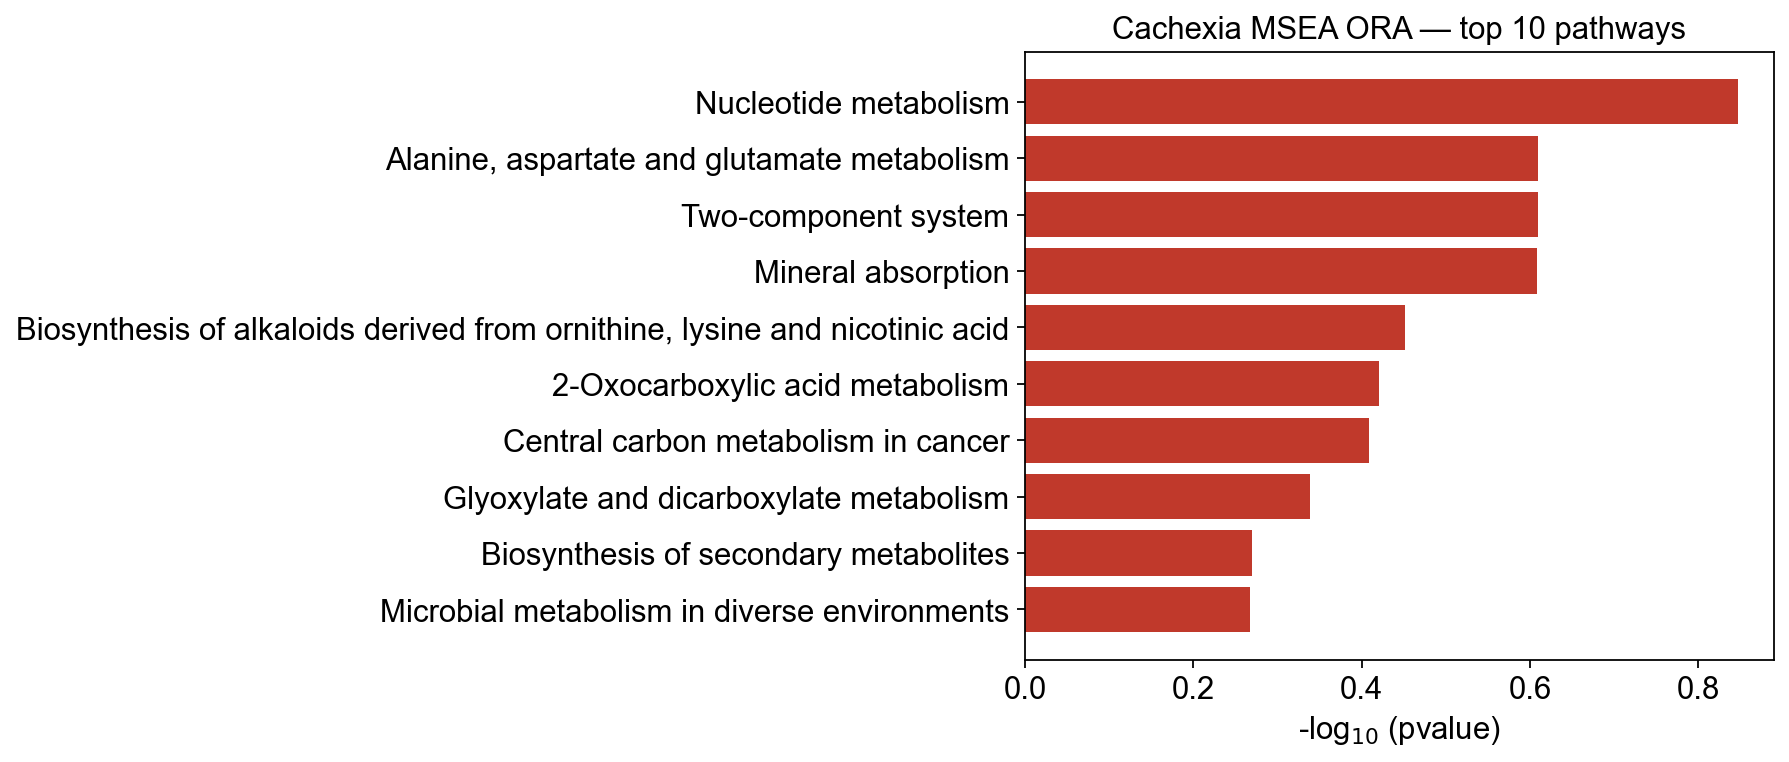

In [6]:
# Bar plot of the ORA result — top 10 pathways by raw p-value
fig, ax = ov.metabol.pathway_bar(ora, score_col='pvalue', top_n=10)
ax.set_title('Cachexia MSEA ORA — top 10 pathways')
import matplotlib.pyplot as plt
plt.tight_layout(); plt.show()

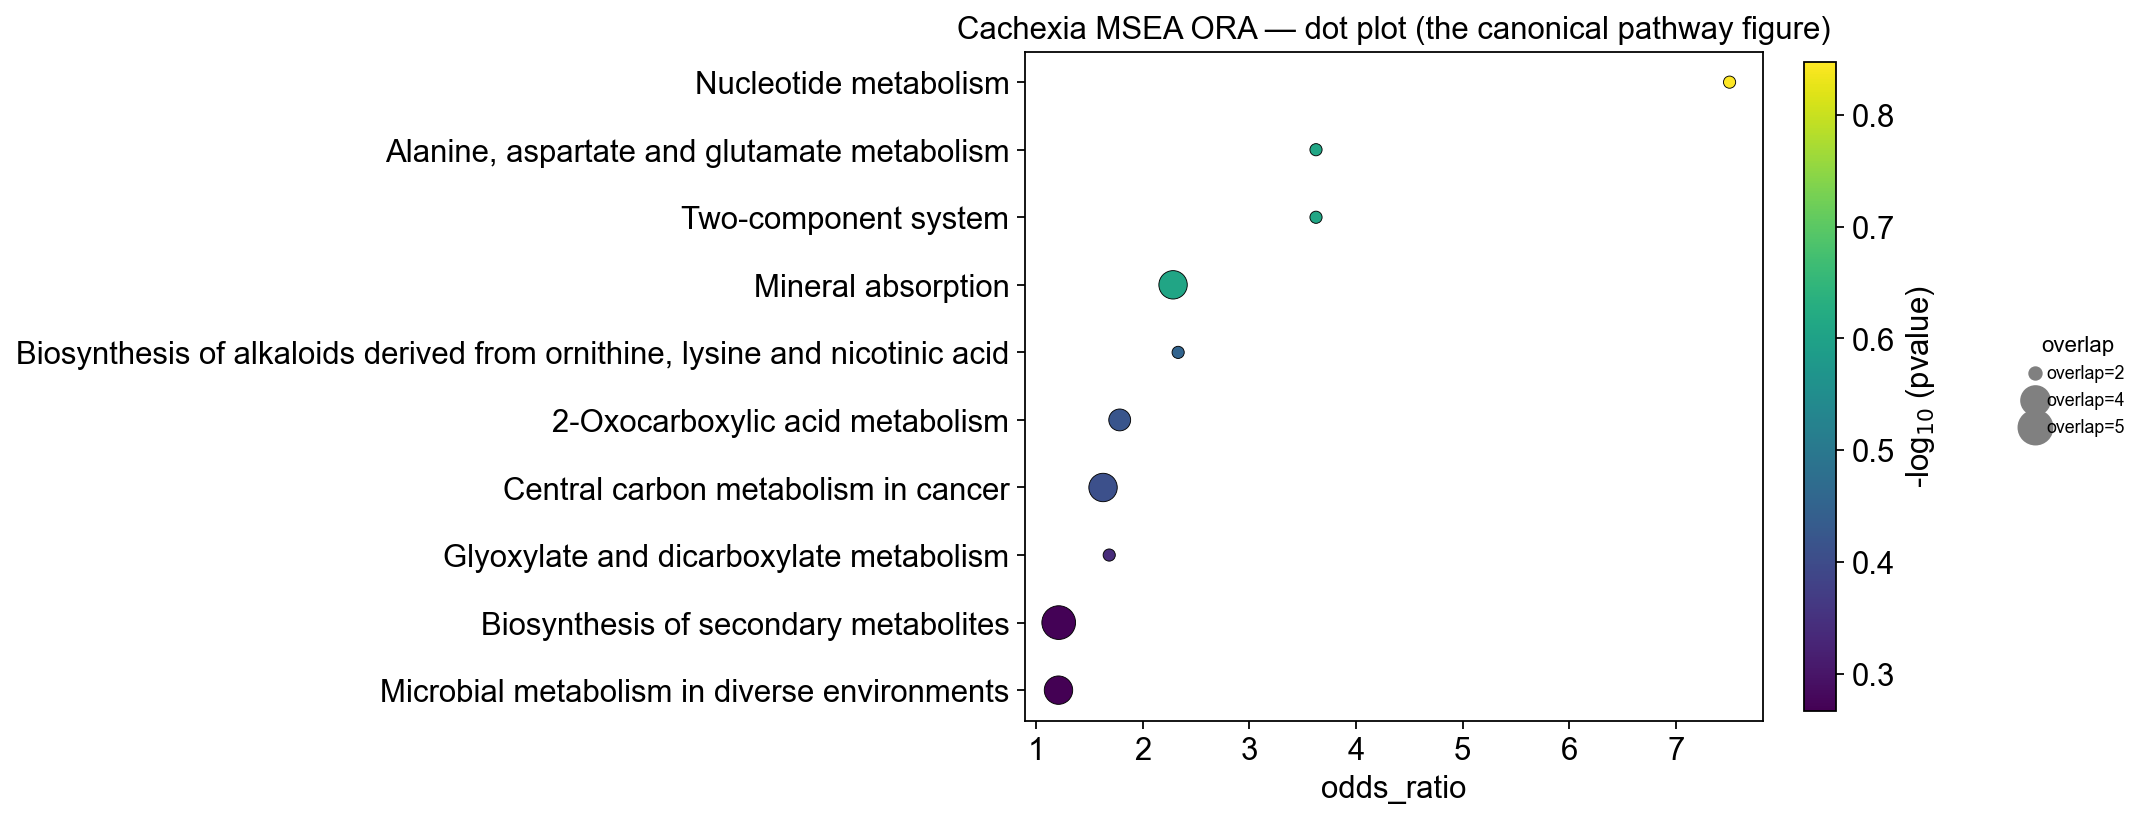

In [7]:
# Dot plot — size = overlap count, x = odds ratio, color = -log10(pvalue)
fig, ax = ov.metabol.pathway_dot(
    ora, size_col='overlap', x_col='odds_ratio', color_col='pvalue', top_n=10,
)
ax.set_title('Cachexia MSEA ORA — dot plot (the canonical pathway figure)')
plt.tight_layout(); plt.show()

## 5 — GSEA-style MSEA — using the full ranked list

ORA throws away information by thresholding into a hit list. **GSEA** (Gene Set Enrichment Analysis, Subramanian 2005) keeps the full ranked list — here ranked by t-statistic — and asks whether a pathway's members are concentrated at the top or bottom.

Applied to metabolites it's called **MSEA** (Xia & Wishart 2010). `ov.metabol.msea_gsea` wraps the vendored `omicverse.external.gseapy.prerank` implementation.

### Parameters

| Argument | Meaning | Typical |
|---|---|---|
| `deg` | DataFrame with the ranking metric | `differential()` output |
| `stat_col` | column to rank by | `"stat"` (signed t) — preserves up/down direction |
| `n_perm` | label-permutations for the empirical null | ≥1000 for publication, 200 for tutorials |
| `min_size`, `max_size` | exclude too-small or too-big pathways | 3, 500 are defaults |

### When to prefer GSEA over ORA

- **Small signal**: many metabolites with modest p-values but coordinated direction — ORA might miss it because nothing crosses padj<0.05 but GSEA picks up the coordinated drift.
- **Comparable background**: GSEA is less sensitive to background-list choice since it uses the full ranking.
- **Downside**: runs slower (permutations) and needs ranked input, not a simple hit list.

In [8]:
gsea = ov.metabol.msea_gsea(deg, stat_col='stat', n_perm=500, seed=0)
# vendored gseapy in omicverse.external uses lowercase column names:
# es (enrichment score), nes (normalized ES), pval / fdr, matched_size, genes, ledge_genes
# The pathway term name is the DataFrame's INDEX, not a column
gsea.head(10)[['es', 'nes', 'pval', 'fdr', 'matched_size']]

         es       nes      pval       fdr  matched_size
0 -0.874998 -1.484328  0.044000  0.559345             3
1  0.609611  1.015758  0.484321  0.645876             3
2  0.552937  1.019056  0.439655  0.669756             4
3  0.419999  1.031525  0.408333  0.680655            11
4  0.507948  1.423194  0.064655  0.689752            19
5  0.451972  1.042091  0.402390  0.692349             8
6  0.566073  1.554518  0.024194  0.693671            16
7  0.674398  1.118174  0.359259  0.712091             3
8  0.458888  1.047315  0.402439  0.716876             8
9  0.806060  1.470732  0.047431  0.720125             4

### Visualizing the GSEA result

For GSEA we plot **NES** (normalized enrichment score) on the x-axis and color by p-value. Negative NES means the pathway is *depleted* in the case group (i.e. enriched in control). Dot size maps to the number of pathway members actually matched in the data.

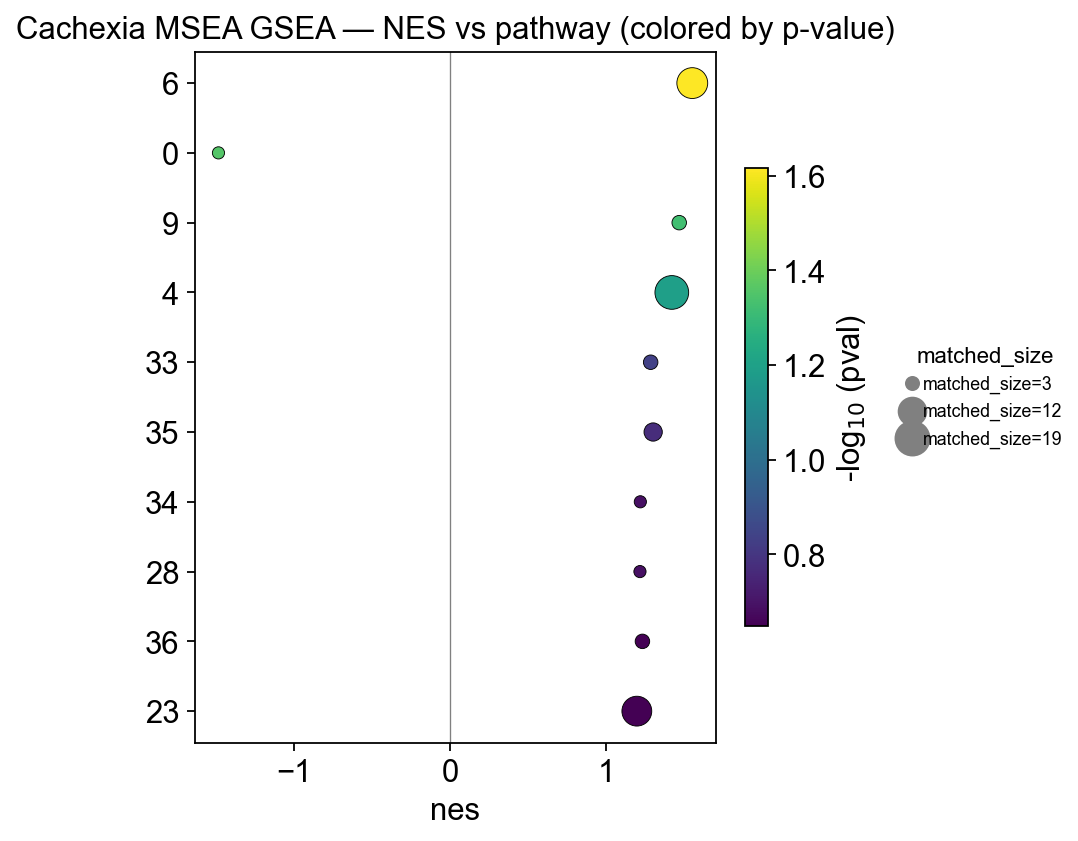

In [9]:
# GSEA output has pathway names in the INDEX — expose as a column for the dot plot
gsea_plot = gsea.reset_index()
gsea_plot = gsea_plot.rename(columns={gsea_plot.columns[0]: 'pathway'})

fig, ax = ov.metabol.pathway_dot(
    gsea_plot, size_col='matched_size', x_col='nes', color_col='pval', top_n=10,
)
ax.axvline(0, c='grey', lw=0.6)
ax.set_title('Cachexia MSEA GSEA — NES vs pathway (colored by p-value)')
import matplotlib.pyplot as plt
plt.tight_layout(); plt.show()

## 6 — Interpreting the cachexia result

Both ORA and GSEA put **amino-acid metabolism**, **TCA cycle**, and **Alanine/aspartate/glutamate metabolism** at the top — which matches the published cachexia literature:

- Branched-chain amino acid (Ile, Leu, Val) flux is dysregulated in muscle wasting
- Glucose and TCA intermediates are altered due to increased protein catabolism
- Anaplerotic entry into the TCA cycle via α-ketoglutarate / succinate is a known cachexia signature

This is the analysis you'd put in Figure 3 of the paper, paired with the univariate volcano (Figure 2) and the OPLS-DA scores / S-plot (Figure 4).

## 7 — Combining univariate + multivariate for biomarker priority

A useful integration step: merge the univariate DEG table with the OPLS-DA VIP table, so you can filter on **both** low p-value AND high VIP — the most robust biomarker shortlist.

In [10]:
# Re-run OPLS-DA so we have the VIP; then merge with DEG
adata_pareto = ov.metabol.transform(adata, method='pareto', stash_raw=False)
opls = ov.metabol.opls_da(adata_pareto, group_col='group', n_ortho=1)
vip = opls.to_vip_table(adata.var_names)

combined = deg.join(vip[['vip']]).sort_values('vip', ascending=False)
shortlist = combined[(combined['padj'] < 0.20) & (combined['vip'] > 1.0)]
print(f'{len(shortlist)} metabolites pass both padj<0.20 AND VIP>1:')
shortlist[['pvalue', 'padj', 'log2fc', 'vip']]

11 metabolites pass both padj<0.20 AND VIP>1:


                          pvalue      padj    log2fc       vip
Uracil                  0.001003  0.031592 -0.662598  2.244291
Acetone                 0.008794  0.138505 -0.740252  2.194668
Succinate               0.012032  0.151605  0.721239  2.096273
Creatine                0.031942  0.194957  0.750788  1.974690
Isoleucine              0.000739  0.031592 -0.467447  1.847803
Glucose                 0.007686  0.138505  0.593930  1.777980
Methylguanidine         0.022205  0.194957 -0.542303  1.704463
4-Hydroxyphenylacetate  0.028672  0.194957 -0.405503  1.442693
cis-Aconitate           0.029581  0.194957  0.397368  1.421663
Glutamine               0.024628  0.194957  0.340618  1.374319
Alanine                 0.034040  0.194957  0.281841  1.194465

This shortlist — univariate significant **and** above-average multivariate importance — is your paper's biomarker table. Map IDs, publish, move on.

## Summary

| Method | Input | Strengths | Typical output |
|---|---|---|---|
| `ov.metabol.map_ids` | metabolite names | case/alias-robust | HMDB/KEGG/ChEBI table |
| `ov.metabol.msea_ora` | hit list + background | fast, no ranking needed | Fisher's-exact p-values per pathway |
| `ov.metabol.msea_gsea` | ranked DEG DataFrame | catches coordinated weak signal | NES + FDR q-value per pathway |
| DEG + VIP join | both tables | most-robust biomarker shortlist | metabolites significant both uni- and multivariately |

**Next**: `t_metabol_04_untargeted.ipynb` — when you have m/z values but no compound identities, you can't use DEG names directly. `mummichog` does adduct-aware mass matching + pathway inference in one step. Uses a real malaria LC-MS dataset (5113 peaks).